# 1st Workflow: HUA Workflow (Housing Unit Analysis)

## Loading the Community

In [1]:
# To reload submodules need to use this magic command to set autoreload on
%load_ext autoreload
%autoreload 2
from pyncoda.ncoda_00g_community_options import *
from IPython.display import display

In [2]:
# select a community from this list
# if your community is not in this list, add it to the file ncoda_00g_community_options.py
list_community_options(communities_dictionary)

['Lumberton, NC: IN-CORE Building inventory for Robeson County, NC',
 'Galveston, TX: IN-CORE Building inventory for Galveston County, TX',
 'Galveston, TX: NSI Building inventory for Galveston County, TX',
 'Galveston, TX: IN-CORE Building inventory for Galveston Island, TX',
 'Mayfield, KY: NSI Building inventory for Graves County, KY',
 'Beaumont, TX: NSI Building inventory for Jefferson County, TX',
 'Beaumont, TX: Safayet Building inventory for Jefferson County, TX',
 'Pentwater, MI: NSI Building inventory for Oceana County, MI',
 'Seaside, OR: NSI Building inventory for Clatsop County, OR',
 'Lane County, OR: NSI Building inventory for Lane County, OR',
 'Benton County, OR: NSI Building inventory for Benton County, OR',
 'Southeast Texas Urban Integrated Field Lab: NSI Building inventory for Southeast Texas',
 'Southeast Texas Urban Integrated Field Lab (12 neighbor counties): NSI Building inventory for Southeast Texas',
 'Brazos County, TX: NSI Building inventory for Brazos Coun

In [3]:
community_id_by_name = 'Galveston, TX: NSI Building inventory for Galveston County, TX'

In [4]:
community_id, focalplace, countyname, countyfips = get_community_id_by_name(community_id_by_name)
communities = {community_id : communities_dictionary[community_id]}

Selected community ID: Galveston_County_TX_NSI
Galveston, TX is in TEXAS
Focal place: Galveston
Galveston, TX is in Galveston County, TX with FIPS code 48167
Use IN-CORE: False


## Setiing up the Environment

In [5]:
import pandas as pd
import geopandas as gpd # For reading in shapefiles
import numpy as np
import sys # For displaying package versions
import os # For managing directories and file paths if drive is mounted
import scooby # Reports Python environment

import contextily as cx # For adding basemap tiles to plot
import matplotlib.pyplot as plt # For plotting and making graphs

In [6]:
# open, read, and execute python program with reusable commands
from pyncoda.ncoda_00d_cleanvarsutils import *
from pyncoda.ncoda_04c_poptableresults import *
from pyncoda.ncoda_07i_process_communities import process_community_workflow

In [7]:
# Generate report of Python environment
base_packages = ['pandas','ipyleaflet','seaborn','contextily']
incore_packages = ['pyincore','pyincore_viz']
check_packages = base_packages + incore_packages
print(scooby.Report(additional=check_packages))


--------------------------------------------------------------------------------
  Date: Mon Apr 20 21:53:09 2026 Central Daylight Time

                OS : Windows (10 10.0.26200 SP0 Multiprocessor Free)
            CPU(s) : 24
           Machine : AMD64
      Architecture : 64bit
               RAM : 15.7 GiB
       Environment : Jupyter

  Python 3.10.14 | packaged by Anaconda, Inc. | (main, May  6 2024, 19:44:50)
  [MSC v.1916 64 bit (AMD64)]

            pandas : 2.2.2
        ipyleaflet : Module not found
           seaborn : 0.13.2
        contextily : 1.6.0
          pyincore : Module not found
      pyincore_viz : Module not found
             numpy : 1.26.4
             scipy : 1.13.1
           IPython : 8.25.0
        matplotlib : 3.8.4
            scooby : 0.10.0

  Intel(R) oneAPI Math Kernel Library Version 2023.1-Product Build 20230303
  for Intel(R) 64 architecture applications
--------------------------------------------------------------------------------


In [7]:
# Check working directory - good practice for relative path access
os.getcwd()

'D:\\000_Projects_UH\\Disability_HUA-PREC_Workflow'

## Run Housing Unit Allocation
### The following code will produce the following outputs:
1. Housing Unit Inventory
2. Address Point Invento y
3. Housing Unit Allocation

In [8]:
basevintage_options = ['2010']

In [9]:
from pyncoda.ncoda_07i_process_communities import process_community_workflow

Running iteration 1 of 2 for basevintage 2010 with seed 9876
Generating Housing Unit Inventory v2.0.0 data for Galveston, TX
Galveston County, TX : county FIPS Code 48167
File already exists, skipping: OutputData_HUA/Galveston_County_TX_NSI/../hui_v2-1-0_Galveston_County_TX_NSI_2010_rs9876.csv
Checking output for huid
Checking output for blockid
Checking output for bgid
Checking output for tractid
Checking output for FIPScounty
Checking output for numprec
Checking output for ownershp
Checking output for race
Checking output for hispan
Checking output for family
Checking output for vacancy
Checking output for gqtype
Checking output for incomegroup
Checking output for hhinc
Checking output for randincome
Checking output for poverty
Checking huid Data Type
   Current type: <class 'pandas.core.series.Series'> Expected type <class 'str'>
Checking blockid Data Type
   Current type: <class 'pandas.core.series.Series'> Expected type <class 'str'>
    Length of blockid is correct
Checking bgid 

C:\Users\swast\anaconda3\envs\pyncoda20240619\lib\site-packages\urllib3\connectionpool.py:1103: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www2.census.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Original Census place data URL: https://www2.census.gov/geo/tiger/TIGER2010/PLACE/2010/tl_2010_48_place10.zip


C:\Users\swast\anaconda3\envs\pyncoda20240619\lib\site-packages\urllib3\connectionpool.py:1103: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www2.census.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Original Census puma data URL: https://www2.census.gov/geo/tiger/TIGER2010/PUMA5/2010/tl_2010_48_puma10.zip


...

Geolevels available ['state', 'county', 'tract']
Geolvarids available ['County2010', 'Tract2010']
Adding County2010 expected length 5
Dataframe has Tract 2010 for new geovar County2010
Confirming County2010 has expected length.
Checking primary key name uniqueidB19001
Primary key variable uniqueidB19001 is unique.
Primary key uniqueidB19001 has no missing values
['uniqueidB19001', 'County2010', 'Tract2010', 'index', 'GEO_ID', 'state', 'county', 'tract', 'race', 'hispan', 'hu_counter', 'family', 'incomegroup', 'family_flagsetrm', 'family_Tract2010_flagsetrm', 'family_County2010_flagsetrm', 'incomegroup_flagsetrm', 'incomegroup_Tract2010_flagsetrm']
Initializing geovar flag set variable for incomegroup at geolevel County2010
New flag: incomegroup_County2010_flagsetrm
Observations without primary flag set 4220
Observations without geovar flag set 111537
After updated observations without geovar flag set 4220
Setting 4220 flags for incomegroup secondary data not used.
0 observations do not

D:\000_Projects_UH\Disability_HUA-PREC_Workflow\pyncoda\CommunitySourceData\api_census_gov\acg_02a_add_categorical_char.py:788: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '7.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  set_flag_df.loc[conditions, self.flaggeo_var] = self.round+.5


After update observations geovar flag set 8 = 1393
    Check random merge results for primary data.
Check by geovar flag incomegroup_County2010_flagsetrm
Observations flag not equal to 0 132551
Input and output data have the same length 132553
Outputdata has 132551 Observations with predicted incomegroup
Percent left to predict:  0.00
    Overwrite input data with update output data.
Flag vars available ['family_flagsetrm', 'family_Tract2010_flagsetrm', 'family_County2010_flagsetrm', 'incomegroup_flagsetrm', 'incomegroup_Tract2010_flagsetrm', 'incomegroup_County2010_flagsetrm']
Before update output_df observations flag set 8 = 0
Before update results observations flag set 8 = 1393
After update observations geovar flag set 8 = 1393
    Check random merge results for secondary data.
Check by geovar flag incomegroup_County2010_flagsetrm
Observations flag not equal to 0 108967
Input and output data have the same length 111537
Outputdata has 108967 Observations with predicted incomegroup
Pe

D:\000_Projects_UH\Disability_HUA-PREC_Workflow\pyncoda\ncoda_07d_run_hua_workflow.py:173: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.5 1.5 1.5 ... 1.5 1.5 1.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  addptv2_df.loc[condition1 & condition2 & condition3,'ownershp1'] \


Round 1
Performing random merge at geography level: Block
Attempt to merge hui on all common group vars.
Running random merge by ['Block2010', 'huicounter3', 'ownershp1']
    Setting up  primary data with primary key and flags
Adding Block2010 to column list
Geolevels available []
Geolvarids available ['Block2010']
Adding Block2010 expected length 15
Dataframe has Block 2010 for new geovar Block2010
Confirming Block2010 has expected length.
Checking primary key name huid
Primary key variable huid is unique.
Primary key huid has no missing values
['huid', 'Block2010', 'blockid', 'bgid', 'tractid', 'FIPScounty', 'numprec', 'ownershp', 'race', 'hispan', 'family', 'vacancy', 'gqtype', 'incomegroup', 'hhinc', 'randincome', 'poverty', 'huicounter1', 'huicounter2', 'huicounter3', 'ownershp1', 'ownershp2', 'ownershp3', 'strctid', 'strctid_flagsetrm', 'strctid_Block2010_flagsetrm', 'addrptid', 'fd_id_bid', 'huestimate', 'huicounter_addpt', 'placeNAME10', 'x', 'y']
Observations without primary f

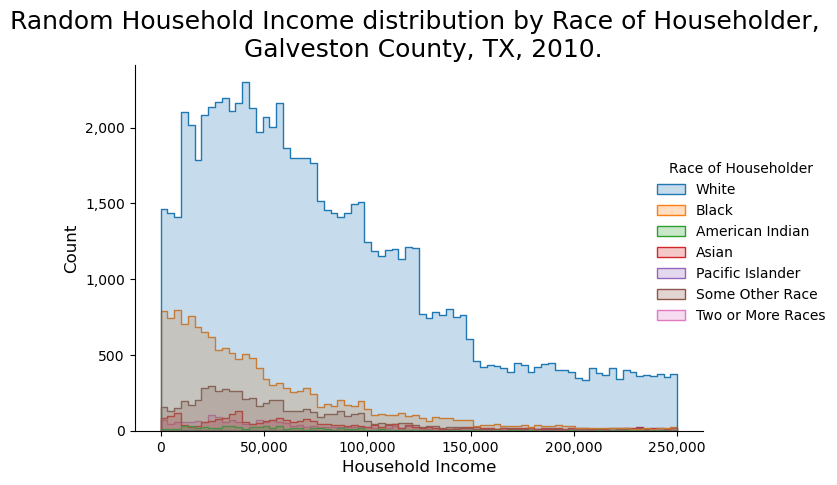

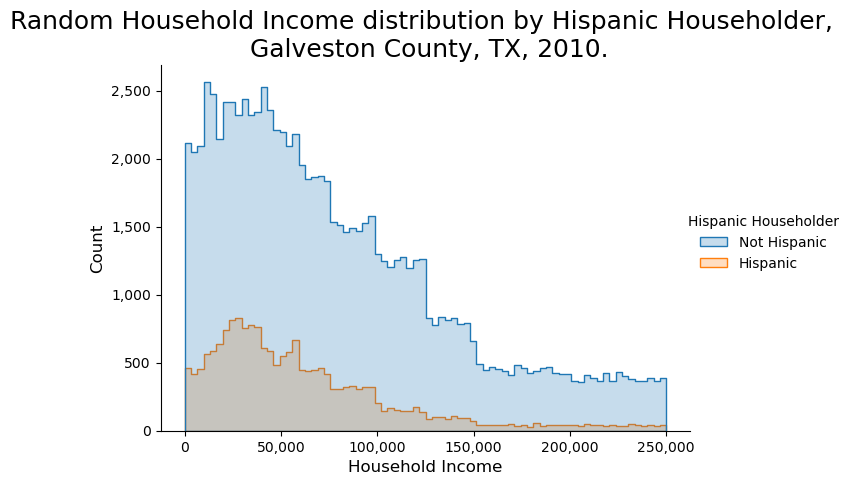

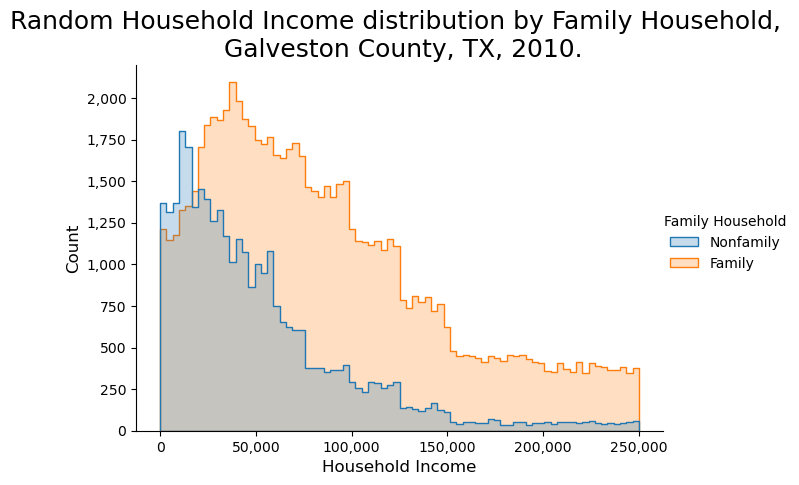

In [12]:
hua_hui_gdf_dict = {}
base_seed = 9876
iterations = 2
# iterate through basevintage options to run Monte Carlo Simulation
for basevintage in basevintage_options:
    hua_hui_gdf_dict[basevintage] = {}
    for i in range(iterations):
        seed_i = base_seed + i
        print(f"Running iteration {i+1} of {iterations} for basevintage {basevintage} with seed {seed_i}")
        workflow = process_community_workflow(
                    communities,
                    seed = seed_i,
                    version = '2.1.0',
                    version_text = 'v2-1-0',
                    basevintage = basevintage,
                    outputfolder ="OutputData_HUA",
                    outputfolders = {},
                    savefiles = True)
        hua_hui_gdf_dict[basevintage][seed_i] = workflow.process_communities()

In [13]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles in this directory:")
print(os.listdir())

Current working directory:
D:\000_Projects_UH\Disability_HUA-PREC_Workflow

Files in this directory:
['.devcontainer', '.git', '.gitattributes', '.github', '.gitignore', '.ipynb_checkpoints', 'Admin', 'Archive', 'CITATION.cff', 'Disability_Galveston_2010', 'environment.yml', 'HUA_Disability.ipynb', 'IN-CORE_HRRC_Banner.png', 'LICENSE', 'ncoda_07fv1_HUA_PREC_NSI_modAZs.ipynb', 'ncoda_07fv3_HUA_PREC_NSI.ipynb', 'ncoda_07gv1_HUI_2020.ipynb', 'ncoda_07hv4_HUA_PREC_NSI.ipynb', 'ncoda_07iv1_SimCenter_HUA.ipynb', 'ncoda_08av1_PyPDFcodebook.ipynb', 'OutputData', 'OutputData_HUA', 'pyncoda', 'pyproject.toml', 'Readings', 'README.md', 'requirements.txt', 'requirements_new.txt', 'SampleOutputData', 'temp.csv']


## Explore and Validate Housing Unit Allocation

### Look at population characteristics and compare to US Census

In [14]:
where = communities[community_id]['community_name']
print(where, focalplace, countyname, countyfips)

Galveston, TX Galveston Galveston County, TX 48167


### 2010 - Total Population by Households by Tenure Status (Seed: 9876)

In [15]:
PopResultsTable.pop_results_table(
                  input_df = hua_hui_gdf_dict['2010'][9876], 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = '2010 (9876)',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied (%),2 Renter Occupied (%),Total Population by Households (%)
Race Ethnicity,,,
"1 White alone, Not Hispanic","137,132 (67.3%)","37,790 (46.2%)","174,922 (61.3%)"
"2 Black alone, Not Hispanic","19,133 (9.4%)","18,281 (22.4%)","37,414 (13.1%)"
"3 American Indian and Alaska Native alone, Not Hispanic",745 (0.4%),360 (0.4%),"1,105 (0.4%)"
"4 Asian alone, Not Hispanic","6,304 (3.1%)","1,717 (2.1%)","8,021 (2.8%)"
"5 Other Race, Not Hispanic","1,989 (1.0%)",931 (1.1%),"2,920 (1.0%)"
"6 Any Race, Hispanic","38,515 (18.9%)","22,638 (27.7%)","61,153 (21.4%)"
Total,"203,818 (100.0%)","81,717 (100.0%)","285,535 (100.0%)"


### 2010 - Total Population by Households by Tenure Status (Seed: 9877)

In [16]:
PopResultsTable.pop_results_table(
                  input_df = hua_hui_gdf_dict['2010'][9877], 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = '2010 (9877)',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied (%),2 Renter Occupied (%),Total Population by Households (%)
Race Ethnicity,,,
"1 White alone, Not Hispanic","137,132 (67.3%)","37,790 (46.2%)","174,922 (61.3%)"
"2 Black alone, Not Hispanic","19,133 (9.4%)","18,281 (22.4%)","37,414 (13.1%)"
"3 American Indian and Alaska Native alone, Not Hispanic",745 (0.4%),360 (0.4%),"1,105 (0.4%)"
"4 Asian alone, Not Hispanic","6,304 (3.1%)","1,717 (2.1%)","8,021 (2.8%)"
"5 Other Race, Not Hispanic","1,989 (1.0%)",931 (1.1%),"2,920 (1.0%)"
"6 Any Race, Hispanic","38,515 (18.9%)","22,638 (27.7%)","61,153 (21.4%)"
Total,"203,818 (100.0%)","81,717 (100.0%)","285,535 (100.0%)"


### 2010 - Total Population by Households by Hispanic (Seed: 9876)

In [17]:
PopResultsTable.pop_results_table(
                  input_df = hua_hui_gdf_dict['2010'][9876], 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = '2010 (9876)',
                  row_index = "Race Ethnicity",
                  col_index = 'Hispanic')

Hispanic,0. Not Hispanic or Latino (%),1. Hispanic or Latino (%),Total Population by Households (%)
Race Ethnicity,,,
"1 White alone, Not Hispanic","174,922 (78.0%)",nan (nan%),"174,922 (61.3%)"
"2 Black alone, Not Hispanic","37,414 (16.7%)",nan (nan%),"37,414 (13.1%)"
"3 American Indian and Alaska Native alone, Not Hispanic","1,105 (0.5%)",nan (nan%),"1,105 (0.4%)"
"4 Asian alone, Not Hispanic","8,021 (3.6%)",nan (nan%),"8,021 (2.8%)"
"5 Other Race, Not Hispanic","2,920 (1.3%)",nan (nan%),"2,920 (1.0%)"
"6 Any Race, Hispanic",nan (nan%),"61,153 (100.0%)","61,153 (21.4%)"
Total,"224,382 (100.0%)","61,153 (100.0%)","285,535 (100.0%)"


In [17]:
### 2010 - Total Population by Households by Hispanic (Seed: 9877)

In [18]:
PopResultsTable.pop_results_table(
                  input_df = hua_hui_gdf_dict['2010'][9877], 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = '2010 (9877)',
                  row_index = "Race Ethnicity",
                  col_index = 'Hispanic')

Hispanic,0. Not Hispanic or Latino (%),1. Hispanic or Latino (%),Total Population by Households (%)
Race Ethnicity,,,
"1 White alone, Not Hispanic","174,922 (78.0%)",nan (nan%),"174,922 (61.3%)"
"2 Black alone, Not Hispanic","37,414 (16.7%)",nan (nan%),"37,414 (13.1%)"
"3 American Indian and Alaska Native alone, Not Hispanic","1,105 (0.5%)",nan (nan%),"1,105 (0.4%)"
"4 Asian alone, Not Hispanic","8,021 (3.6%)",nan (nan%),"8,021 (2.8%)"
"5 Other Race, Not Hispanic","2,920 (1.3%)",nan (nan%),"2,920 (1.0%)"
"6 Any Race, Hispanic",nan (nan%),"61,153 (100.0%)","61,153 (21.4%)"
Total,"224,382 (100.0%)","61,153 (100.0%)","285,535 (100.0%)"


### 2010 - Median Household Income by Tanure (Seed: 9876)

In [23]:
PopResultsTable.pop_results_table(hua_hui_gdf_dict['2010'][9876], 
                   who = "Median Household Income", 
                  what = "by Race, Ethnicity",
                  where = where,
                  when = '2010 (9876)',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied,2 Renter Occupied,Median Household Income
Race Ethnicity,,,
"1 White alone, Not Hispanic","$78,736","$56,151","$72,383"
"2 Black alone, Not Hispanic","$42,296","$31,077","$36,902"
"3 American Indian and Alaska Native alone, Not Hispanic","$59,526","$39,506","$50,694"
"4 Asian alone, Not Hispanic","$70,125","$42,263","$62,442"
"5 Other Race, Not Hispanic","$64,646","$48,807","$56,435"
"6 Any Race, Hispanic","$54,887","$42,095","$49,451"
Total,"$69,917","$46,214","$61,680"


### 2010 - Median Household Income by Tanure (Seed: 9877)

In [24]:
PopResultsTable.pop_results_table(hua_hui_gdf_dict['2010'][9877], 
                   who = "Median Household Income", 
                  what = "by Race, Ethnicity",
                  where = where,
                  when = '2010 (9877)',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied,2 Renter Occupied,Median Household Income
Race Ethnicity,,,
"1 White alone, Not Hispanic","$78,810","$55,699","$72,637"
"2 Black alone, Not Hispanic","$42,644","$31,120","$37,116"
"3 American Indian and Alaska Native alone, Not Hispanic","$58,301","$46,700","$51,672"
"4 Asian alone, Not Hispanic","$71,362","$41,102","$63,766"
"5 Other Race, Not Hispanic","$63,261","$48,401","$55,696"
"6 Any Race, Hispanic","$54,566","$41,762","$49,218"
Total,"$70,174","$46,263","$61,865"


### Validation

In [28]:
print("Total Population by Race and Ethnicity:")
print(f"https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=DECENNIALSF12010.P5")

print("Median Income by Race and Ethnicity:")
print(f"All Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2012.B19013")
print(f"Black Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2012.B19013B")
print(f"White, not Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2012.B19013H")
print(f"Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2012.B19013I")

Total Population by Race and Ethnicity:
https://data.census.gov/cedsci/table?g=050XX00US48167&tid=DECENNIALSF12010.P5
Median Income by Race and Ethnicity:
All Households: https://data.census.gov/cedsci/table?g=050XX00US48167&tid=ACSDT5Y2012.B19013
Black Households: https://data.census.gov/cedsci/table?g=050XX00US48167&tid=ACSDT5Y2012.B19013B
White, not Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US48167&tid=ACSDT5Y2012.B19013H
Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US48167&tid=ACSDT5Y2012.B19013I


### Explore Maps

In [29]:
focalplace

'Galveston'

In [30]:
hua_hui_race_gdf_dict = {}
county_hua_gdf_dict = {}
focal_place_hua_gdf_dict = {}

In [31]:
# Import all three modules to make their functions available
from pyncoda import ncoda_04c_poptableresults
from pyncoda import ncoda_04a_Figures
from pyncoda import ncoda_04b_foliummaps

# Import everything from these modules (makes all functions directly accessible)
from pyncoda.ncoda_04c_poptableresults import *
from pyncoda.ncoda_04a_Figures import *
from pyncoda.ncoda_04b_foliummaps import *

print("✓ All three modules imported successfully")


✓ All three modules imported successfully


[-95.10263749625479, -94.74190570975937] [29.10027320906348, 29.32609229614067]


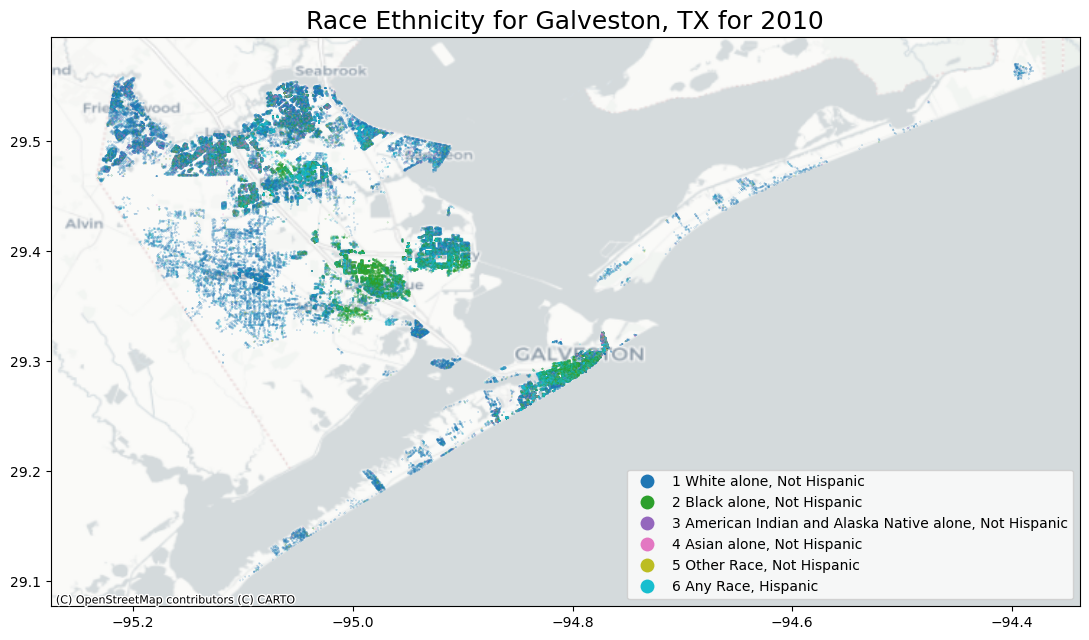

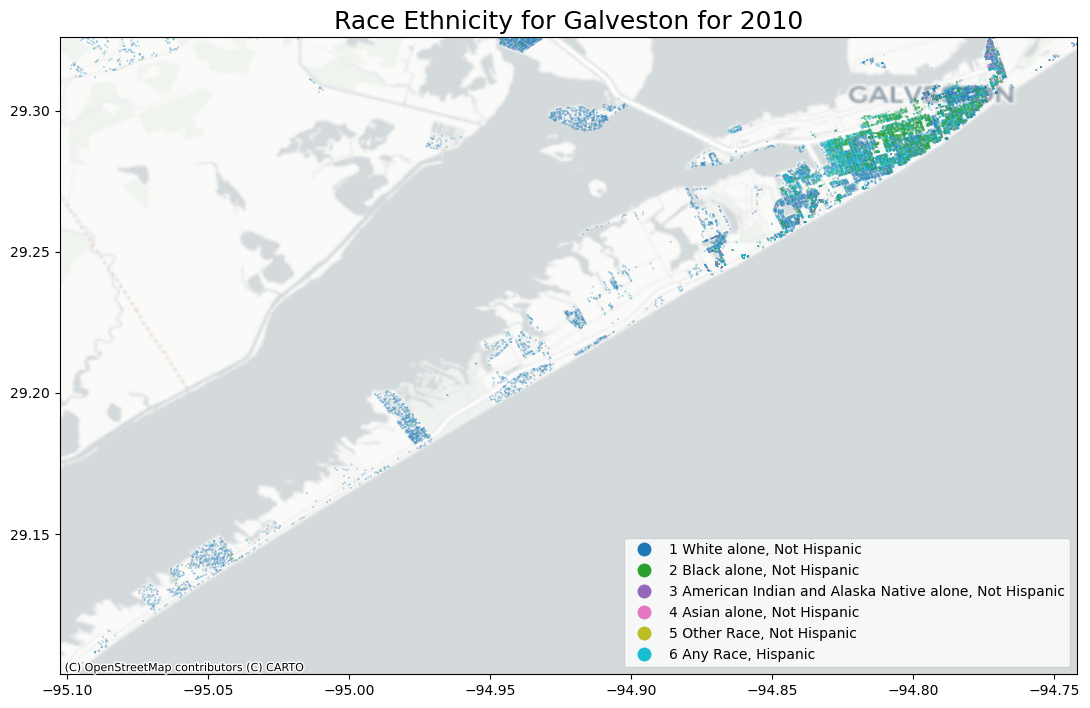

In [32]:

seed_i = 9876

for year in ['2010']:
    # add race ethnicity to data frame for better map legends
    hua_hui_race_gdf_dict[year] = PopResultsTable.add_race_ethnicity_to_pop_df(hua_hui_gdf_dict[year][seed_i])

    #mapname = 'hhincdotmap'
    mapname = f'hhracedotmap_{year}'
    # Map column
    #map_var = 'Household Income Group'
    map_var = 'Race Ethnicity'
    place = focalplace

    yr = str(year)[2:4]
    condition1 = "(hua_hui_race_gdf_dict[year].race >= 1)"
    condition2 = f"(hua_hui_race_gdf_dict[year].placeNAME{yr} == '{place}')"
    conditions = f"{condition1} & {condition2}"

    county_hua_gdf_dict[year] = hua_hui_race_gdf_dict[year].loc[eval(condition1)].copy(deep=True)
    county_hua_gdf_dict[year] = county_hua_gdf_dict[year].to_crs(epsg=4326)
    focal_place_hua_gdf_dict[year] = hua_hui_race_gdf_dict[year].loc[eval(conditions)].copy(deep=True)
    focal_place_hua_gdf_dict[year] = focal_place_hua_gdf_dict[year].to_crs(epsg=4326)

    bldg_inv_id = communities[community_id]['building_inventory']['id']
    outputfolder = 'OutputData_HUA'
    community = communities[community_id]['community_name']

    county_map = plot_dotmap_map(gdf=county_hua_gdf_dict[year],
                            mapname=mapname,
                            map_var=map_var,
                            bldg_inv_id=bldg_inv_id,
                            community=community_id,
                            place = community,
                            year = year,
                            outputfolder=outputfolder,
                            condition_id = "1",
                            basemap_source = cx.providers.CartoDB.Positron)
    
    # get xlim and ylim for focal place
    xlim = [focal_place_hua_gdf_dict[year].total_bounds[0], focal_place_hua_gdf_dict[year].total_bounds[2]]
    ylim = [focal_place_hua_gdf_dict[year].total_bounds[1], focal_place_hua_gdf_dict[year].total_bounds[3]]
    print(xlim, ylim)

    focal_place_map = plot_dotmap_map(gdf=county_hua_gdf_dict[year],
                        mapname=mapname,
                        map_var=map_var,
                        bldg_inv_id=bldg_inv_id,
                        community=community_id,
                        place = focalplace,
                        year = year,
                        outputfolder=outputfolder,
                        condition_id = "2",
                        basemap_source = cx.providers.CartoDB.Positron,
                        xlim = xlim,
                        ylim = ylim,
                        focal_gdf = focal_place_hua_gdf_dict[year])

### Spatial Analysis

In [33]:
# Install individually
# !pip install esda --break-system-packages
# !pip install libpysal --break-system-packages
# !pip install splot --break-system-packages
# !pip install spreg --break-system-packages

In [34]:
# convert county name to string with _ instead of spaces
filename = "Galveston_County_TX_NSI"

# 2nd Workflow: PREC Workflow (Person Records with Disability)

In [35]:
# ==============================================================
# Step 1: Setup — imports and community configuration
# ==============================================================

%load_ext autoreload
%autoreload 2

import os
import pandas as pd
import numpy as np
from IPython.display import display

from pyncoda.ncoda_00g_community_options import *
from pyncoda.CommunitySourceData.api_census_gov.acg_01a_BaseInventory import BaseInventory
from pyncoda.CommunitySourceData.api_census_gov.acg_00f_preci_block2010 import sexbyage_P12_varstem_roots
from pyncoda.CommunitySourceData.api_census_gov.acg_00a_createAPI_datastructure import createAPI_datastructure

# --- Community Setup ---
community_id_by_name = 'Galveston, TX: NSI Building inventory for Galveston County, TX'
community_id, focalplace, countyname, countyfips = get_community_id_by_name(community_id_by_name)

state_county      = countyfips
state_county_name = countyname
seed              = 9876
basevintage       = '2010'

# --- Output folders ---
prec_outputfolder = "OutputData_PREC"
prec_base = f"{prec_outputfolder}/{community_id}"

prec_outputfolders = {
    'top'                    : prec_base,
    'logfiles'               : f"{prec_base}/00_logfiles",
    'CommunitySourceData'    : f"{prec_base}/01_CommunitySourceData",
    'TidyCommunitySourceData': f"{prec_base}/02_TidyCommunitySourceData",
    'BaseInventory'          : f"{prec_base}/03_BaseInventory",
    'RandomMerge'            : f"{prec_base}/04_RandomMerge",
}
for folder in prec_outputfolders.values():
    os.makedirs(folder, exist_ok=True)

print(f"Community    : {community_id}")
print(f"State/County : {state_county} — {state_county_name}")
print(f"Seed         : {seed}")
print(f"Base vintage : {basevintage}")
print("Folders ready ✓")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Selected community ID: Galveston_County_TX_NSI
Galveston, TX is in TEXAS
Focal place: Galveston
Galveston, TX is in Galveston County, TX with FIPS code 48167
Use IN-CORE: False
Community    : Galveston_County_TX_NSI
State/County : 48167 — Galveston County, TX
Seed         : 9876
Base vintage : 2010
Folders ready ✓


In [36]:
# ==============================================================
# Step 2: Create block-level person records from P12 (Sex by Age)
# ==============================================================
block_df = {}

block_df['preci'] = BaseInventory.get_apidata(
    state_county  = state_county,
    geo_level     = 'block',
    vintage       = basevintage,
    mutually_exclusive_varstems_roots_dictionaries = [sexbyage_P12_varstem_roots],
    outputfolders = prec_outputfolders,
    outputfile    = 'CorePREC'
)

print(f"\nStep 2 complete: Block-level person records created.")
print(f"Shape   : {block_df['preci'].shape}")
print(f"Columns : {list(block_df['preci'].columns)}")
display(block_df['preci'].head(3))

{'top': 'OutputData_PREC/Galveston_County_TX_NSI', 'logfiles': 'OutputData_PREC/Galveston_County_TX_NSI/00_logfiles', 'CommunitySourceData': 'OutputData_PREC/Galveston_County_TX_NSI/01_CommunitySourceData', 'TidyCommunitySourceData': 'OutputData_PREC/Galveston_County_TX_NSI/02_TidyCommunitySourceData', 'BaseInventory': 'OutputData_PREC/Galveston_County_TX_NSI/03_BaseInventory', 'RandomMerge': 'OutputData_PREC/Galveston_County_TX_NSI/04_RandomMerge'}
['sex', 'minageyrs', 'maxageyrs', 'byracehispan']

**********************************
Obtain data from Census API SEX BY AGE FOR SELECTED AGE CATEGORIES
    Obtaining data for P012 SEX BY AGE FOR SELECTED AGE CATEGORIES by Total
       Census API data from: https://api.census.gov/data/2010/dec/sf1?get=GEO_ID,P012003,P012004,P012005,P012006,P012007,P012008,P012009,P012010,P012011,P012012,P012013,P012014,P012015,P012016,P012017,P012018,P012019,P012020,P012021,P012022,P012023,P012024,P012025,P012027,P012028,P012029,P012030,P012031,P012032,P012

,precid,Block2010,Block2010str,sex,minageyrs,maxageyrs,race,hispan,prec_counter
0,B481677201001000P0001,481677201001000,B481677201001000,1,0,4,1,0,1
1,B481677201001000P0002,481677201001000,B481677201001000,1,0,4,1,0,2
2,B481677201001000P0003,481677201001000,B481677201001000,1,0,4,1,0,3


In [37]:
# ==============================================================
# Step 3: Add Hispanic ethnicity via graft method
# ==============================================================

from pyncoda.CommunitySourceData.api_census_gov.acg_00f_preci_block2010 import (
    sexbyage_P12HAI_varstem_roots,
    hispan_byrace_P5_varstem_roots
)

block_df['precihispan'] = BaseInventory.graft_on_new_char(
    base_inventory        = block_df['preci'],
    state_county          = state_county,
    new_char              = 'hispan',
    new_char_dictionaries = [
        sexbyage_P12HAI_varstem_roots,
        hispan_byrace_P5_varstem_roots
    ],
    outputfile    = 'preci',
    outputfolders = prec_outputfolders
)

print(f"\nStep 3 complete: Hispanic ethnicity added.")
print(f"Shape   : {block_df['precihispan'].shape}")
print(f"Columns : {list(block_df['precihispan'].columns)}")
print(f"\nhispan value counts:")
print(block_df['precihispan']['hispan'].value_counts().sort_index())
display(block_df['precihispan'].head(3))

Base Housing Unit Inventory has new characteristic hispan
Graft process will predict missing values of  hispan

***************************************
    Base Inventory has 80221 observations not set
***************************************


***************************************
    Predicting hispan based on ['sex', 'minageyrs', 'maxageyrs', 'hispanbyP12HAI', 'byracehispan'] ['sex', 'minageyrs', 'maxageyrs'] P12HAI
***************************************


***************************************
    Base Inventory has 80221 observations not set
***************************************

['sex', 'minageyrs', 'maxageyrs', 'hispanbyP12HAI', 'byracehispan']

**********************************
Obtain data from Census API SEX BY AGE FOR SELECTED AGE CATEGORIES
    Obtaining data for P012A SEX BY AGE FOR SELECTED AGE CATEGORIES by White alone
Dictionary file OutputData_PREC/Galveston_County_TX_NSI/01_CommunitySourceData/api_census_gov/P012A_48167_2010.json Already exists - Skipping API Cal

,precid,Block2010,Block2010str,sex,minageyrs,maxageyrs,race,hispan,prec_counter,hispan_flag,...,sumby_hispanbyP12HAI,prob_hispanbyP12HAI,hispanbyP5,preccount_hispanbyP5,sumby_hispanbyP5,prob_hispanbyP5,hispanbyP12HAI_counter,hispanbyP5_counter,preccount_hispanbyP12HAIupdated,preccount_hispanbyP5updated
0,B481677201001000P0001,481677201001000,B481677201001000,1.0,0.0,4.0,1.0,0.0,1.0,hispan set to 0 by core hui,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,B481677201001000P0002,481677201001000,B481677201001000,1.0,0.0,4.0,1.0,0.0,2.0,hispan set to 0 by core hui,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,B481677201001000P0003,481677201001000,B481677201001000,1.0,0.0,4.0,1.0,0.0,3.0,hispan set to 0 by core hui,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
# ==============================================================
# Step 4: Add random age to block and tract records
# ==============================================================

from pyncoda.CommunitySourceData.api_census_gov.acg_02c_agefunctions import (
    add_randage,
    add_P12age_groups
)

# --- Step 4a: Add random age to block-level person records ---
block_df['precihispan'] = add_randage(
    block_df['precihispan'],
    seed    = seed,
    varname = 'randageP12'
)
block_df['precihispan'] = add_P12age_groups(
    block_df['precihispan'],
    varname = 'randageP12'
)

print(f"Step 4a complete: Random age added to block records.")
print(f"Shape      : {block_df['precihispan'].shape}")
print(f"\nrandageP12 sample stats:")
print(block_df['precihispan']['randageP12'].describe())
print(f"\nagegroupP12 value counts:")
print(block_df['precihispan']['agegroupP12'].value_counts().sort_index())

Step 4a complete: Random age added to block records.
Shape      : (291309, 26)

randageP12 sample stats:
count    291309.000000
mean         36.259343
std          22.540015
min           0.000000
25%          16.000000
50%          36.000000
75%          53.000000
max         109.000000
Name: randageP12, dtype: float64

agegroupP12 value counts:
agegroupP12
1.0     19979
2.0     20559
3.0     20821
4.0     12808
5.0      8044
6.0      3564
7.0      3254
8.0     10681
9.0     18818
10.0    18902
11.0    19450
12.0    19756
13.0    22969
14.0    23153
15.0    19978
16.0     6792
17.0     8977
18.0     4941
19.0     6226
20.0     7755
21.0     5803
22.0     4412
23.0     3667
Name: count, dtype: int64


In [40]:
# ==============================================================
# Step 5: Fetch tract-level PCT12 data and add random age
# ==============================================================

tract_df = {}
group = 'PCT12'

# --- Step 5a: Fetch PCT12 variable structure ---
sexbyage_PCT12_varstem_roots = createAPI_datastructure.obtain_api_metadata(
    vintage      = '2010',
    dataset_name = 'dec/sf1',
    group        = group,
    outputfolder = prec_outputfolder
)

# --- Step 5b: Pull tract-level PCT12 data ---
tract_df['PCT12'] = BaseInventory.get_apidata(
    state_county  = state_county,
    geo_level     = 'tract',
    vintage       = '2010',
    mutually_exclusive_varstems_roots_dictionaries = [sexbyage_PCT12_varstem_roots],
    outputfolders = prec_outputfolders,
    outputfile    = group
)

# --- Step 5c: Add random age to tract records ---
tract_df['PCT12'] = add_randage(
    tract_df['PCT12'],
    seed    = seed,
    varname = 'randagePCT12'
)
tract_df['PCT12'] = add_P12age_groups(
    tract_df['PCT12'],
    varname = 'randagePCT12'
)

print(f"Step 5 complete: Tract-level PCT12 data fetched and age added.")
print(f"Shape   : {tract_df['PCT12'].shape}")
print(f"Columns : {list(tract_df['PCT12'].columns)}")
print(f"\nrandagePCT12 sample stats:")
print(tract_df['PCT12']['randagePCT12'].describe())
display(tract_df['PCT12'].head(3))

Obtaining data stucture for PCT12
Check weblink for variable list: https://api.census.gov/data/2010/dec/sf1/groups/PCT12.html.
Assume reached the end of variable list with PCT012210
dict_keys(['metadata', 'PCT012'])
Remove 001 from dictionary.
Remove 002 from dictionary.
Remove 106 from dictionary.
Data structure has 206 variables.
Data structure for API call will have too many variables.
Census API limits data to 50 variables - including GEOID and geovars.
Need to split up varstem into parts.
Max variables for API call reached. Starting new varstem part 2
Max variables for API call reached. Starting new varstem part 3
Max variables for API call reached. Starting new varstem part 4
Max variables for API call reached. Starting new varstem part 5
{'top': 'OutputData_PREC/Galveston_County_TX_NSI', 'logfiles': 'OutputData_PREC/Galveston_County_TX_NSI/00_logfiles', 'CommunitySourceData': 'OutputData_PREC/Galveston_County_TX_NSI/01_CommunitySourceData', 'TidyCommunitySourceData': 'OutputData

,index,GEO_ID,state,county,tract,sex,minageyrs,maxageyrs,prec_counter,randagePCT12,agegroupP12
0,0,1400000US48167720100,48,167,720100,1,0,0,1,0.0,1.0
1,0,1400000US48167720100,48,167,720100,1,0,0,2,0.0,1.0
2,0,1400000US48167720100,48,167,720100,1,0,0,3,0.0,1.0


In [41]:
# ==============================================================
# Step 6a: Random merge tract age onto block person records
# ==============================================================

from pyncoda.CommunitySourceData.api_census_gov.acg_02a_add_categorical_char import add_new_char_by_random_merge_2dfs

add_age = add_new_char_by_random_merge_2dfs(
    dfs = {
        'primary'  : {'data'       : block_df['precihispan'],
                      'primarykey' : 'precid',
                      'geolevel'   : 'Block',
                      'geovintage' : '2010',
                      'notes'      : 'Block age, sex, race, ethnicity data.'},
        'secondary': {'data'       : tract_df['PCT12'],
                      'primarykey' : 'uniqueidPCT12',
                      'geolevel'   : 'Tract',
                      'geovintage' : '2010',
                      'notes'      : 'Tract single-year age, sex data.'}
    },
    seed              = seed,
    common_group_vars = ['agegroupP12'],
    new_char          = 'randagePCT12',
    geolevel          = 'Tract',
    geovintage        = '2010',
    by_groups         = {'All': {'by_variables': ['sex']}},
    fillna_value      = -999,
    state_county      = state_county,
    outputfile        = 'preci_randomage',
    outputfolder      = prec_outputfolders['RandomMerge']
)

rounds = {'options': {
    'option1': {
        'notes'            : 'By original common group vars and by groups variables.',
        'common_group_vars': add_age.common_group_vars,
        'by_groups'        : add_age.by_groups
    }},
    'geo_levels': ['Tract']
}

prec_age_df = add_age.run_random_merge_2dfs(rounds)

# Sanity check
primary_df = prec_age_df['primary']
print(f"\nStep 6 complete: Tract age merged onto block person records.")
print(f"Shape   : {primary_df.shape}")
print(f"Columns : {list(primary_df.columns)}")
print(f"\nrandagePCT12 assignment flags:")
print(primary_df['randagePCT12_flagsetrm'].value_counts().sort_index())
print(f"\nrandagePCT12 stats:")
print(primary_df['randagePCT12'].describe())
display(primary_df.head(3))

Round 1
Performing random merge at geography level: Tract
By original common group vars and by groups variables.
Running random merge by ['Tract2010', 'sex', 'agegroupP12']
    Setting up  primary data with primary key and flags
Geolevels available []
Geolvarids available ['Block2010']
Adding Tract2010 expected length 11
Dataframe has Block 2010 for new geovar Tract2010
Confirming Tract2010 has expected length.
Checking primary key name precid
Primary key variable precid is unique.
Primary key precid has no missing values
Initializing primary flag set variable for randagePCT12
New flag: randagePCT12_flagsetrm
['precid', 'Tract2010', 'Block2010', 'Block2010str', 'sex', 'minageyrs', 'maxageyrs', 'race', 'hispan', 'prec_counter', 'hispan_flag', 'hispan_flagset', 'totalprob_hispan', 'hispanbyP12HAI', 'preccount_hispanbyP12HAI', 'sumby_hispanbyP12HAI', 'prob_hispanbyP12HAI', 'hispanbyP5', 'preccount_hispanbyP5', 'sumby_hispanbyP5', 'prob_hispanbyP5', 'hispanbyP12HAI_counter', 'hispanbyP5_co

D:\000_Projects_UH\Disability_HUA-PREC_Workflow\pyncoda\CommunitySourceData\api_census_gov\acg_02a_add_categorical_char.py:788: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  set_flag_df.loc[conditions, self.flaggeo_var] = self.round+.5


Flag vars available ['randagePCT12_flagsetrm', 'randagePCT12_Tract2010_flagsetrm']
Before update output_df observations flag set 1 = 0
Before update results observations flag set 1 = 291309
After update observations geovar flag set 1 = 291309
    Check random merge results for primary data.
Check by geovar flag randagePCT12_Tract2010_flagsetrm
Observations flag not equal to 0 291309
Input and output data have the same length 291309
Outputdata has 291309 Observations with predicted randagePCT12
Percent left to predict:  0.00
    Overwrite input data with update output data.
Flag vars available ['randagePCT12_flagsetrm', 'randagePCT12_Tract2010_flagsetrm']
Before update output_df observations flag set 1 = 0
Before update results observations flag set 1 = 291309
After update observations geovar flag set 1 = 291309
    Check random merge results for secondary data.
Check by geovar flag randagePCT12_Tract2010_flagsetrm
Observations flag not equal to 0 291309
Input and output data have the s

,precid,Tract2010,Block2010,Block2010str,sex,minageyrs,maxageyrs,race,hispan,prec_counter,...,prob_hispanbyP5,hispanbyP12HAI_counter,hispanbyP5_counter,preccount_hispanbyP12HAIupdated,preccount_hispanbyP5updated,randageP12,agegroupP12,randagePCT12,randagePCT12_flagsetrm,randagePCT12_Tract2010_flagsetrm
0,B481677201001000P0001,48167720100,481677201001000,B481677201001000,1.0,0.0,4.0,1.0,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,3.0,1.0,0.0,1,1.0
1,B481677201001000P0002,48167720100,481677201001000,B481677201001000,1.0,0.0,4.0,1.0,0.0,2.0,...,NaN,NaN,NaN,NaN,NaN,2.0,1.0,0.0,1,1.0
2,B481677201001000P0003,48167720100,481677201001000,B481677201001000,1.0,0.0,4.0,1.0,0.0,3.0,...,NaN,NaN,NaN,NaN,NaN,3.0,1.0,3.0,1,1.0


In [42]:
# Check vintage, dataset, and structure of all 7 disability tables (B18101–B18107)
from pyncoda.CommunitySourceData.api_census_gov.acg_00h_disability_ACS5yr2012 import (
    disability_B18101_varstem_roots,
    disability_B18102_varstem_roots,
    disability_B18103_varstem_roots,
    disability_B18104_varstem_roots,
    disability_B18105_varstem_roots,
    disability_B18106_varstem_roots,
    disability_B18107_varstem_roots,
)

all_dicts = {
    'B18101 (overall disability)':       disability_B18101_varstem_roots,
    'B18102 (hearing difficulty)':       disability_B18102_varstem_roots,
    'B18103 (vision difficulty)':        disability_B18103_varstem_roots,
    'B18104 (cognitive difficulty)':     disability_B18104_varstem_roots,
    'B18105 (ambulatory difficulty)':    disability_B18105_varstem_roots,
    'B18106 (self-care difficulty)':     disability_B18106_varstem_roots,
    'B18107 (indep. living difficulty)': disability_B18107_varstem_roots,
}

for name, d in all_dicts.items():
    md = d['metadata']
    var_count = len(d[md['group'] + '_'])   # e.g. d['B18101_']
    print(f"{name}")
    print(f"  vintage      : {md['vintage']}")
    print(f"  dataset_name : {md['dataset_name']}")
    print(f"  new_char     : {md['new_char']}")
    print(f"  char_vars    : {md['char_vars']}")
    print(f"  variables    : {var_count} variable codes")
    print()

B18101 (overall disability)
  vintage      : 2012
  dataset_name : acs/acs5
  new_char     : disability
  char_vars    : ['sex', 'agegroupB18101', 'disability']
  variables    : 24 variable codes

B18102 (hearing difficulty)
  vintage      : 2012
  dataset_name : acs/acs5
  new_char     : hearing_difficulty
  char_vars    : ['sex', 'agegroupB18101', 'hearing_difficulty']
  variables    : 24 variable codes

B18103 (vision difficulty)
  vintage      : 2012
  dataset_name : acs/acs5
  new_char     : vision_difficulty
  char_vars    : ['sex', 'agegroupB18101', 'vision_difficulty']
  variables    : 24 variable codes

B18104 (cognitive difficulty)
  vintage      : 2012
  dataset_name : acs/acs5
  new_char     : cognitive_difficulty
  char_vars    : ['sex', 'agegroupB18101', 'cognitive_difficulty']
  variables    : 20 variable codes

B18105 (ambulatory difficulty)
  vintage      : 2012
  dataset_name : acs/acs5
  new_char     : ambulatory_difficulty
  char_vars    : ['sex', 'agegroupB18101', 

In [43]:
import requests

# Test the exact URL the API is calling
url = ("https://api.census.gov/data/2012/acs/acs5"
       "?get=GEO_ID,B18101_004E,B18101_005E"
       "&in=state:48&in=county:167&for=tract:*")

# Also try without underscore (as the code is using)
url2 = ("https://api.census.gov/data/2012/acs/acs5"
        "?get=GEO_ID,B18101004E,B18101005E"
        "&in=state:48&in=county:167&for=tract:*")

r1 = requests.get(url)
print(f"URL with underscore - Status: {r1.status_code}")
print(r1.text[:300])

print()

r2 = requests.get(url2)
print(f"URL without underscore - Status: {r2.status_code}")
print(r2.text[:300])

URL with underscore - Status: 200
[["GEO_ID","B18101_004E","B18101_005E","state","county","tract"],
["1400000US48167720700","0","187","48","167","720700"],
["1400000US48167723600","0","184","48","167","723600"],
["1400000US48167721000","0","64","48","167","721000"],
["1400000US48167723000","0","91","48","167","723000"],
["1400000US4

URL without underscore - Status: 400
error: unknown variable 'B18101004E'


In [45]:
# ==============================================================
# Step 6b: Fetch tract-level disability data (B18101–B18107)
# ==============================================================
from pyncoda.CommunitySourceData.api_census_gov.acg_01a_BaseInventory import BaseInventory
from pyncoda.CommunitySourceData.api_census_gov.acg_00h_disability_ACS5yr2012 import (
    disability_B18101_varstem_roots,
    disability_B18102_varstem_roots,
    disability_B18103_varstem_roots,
    disability_B18104_varstem_roots,
    disability_B18105_varstem_roots,
    disability_B18106_varstem_roots,
    disability_B18107_varstem_roots,
)

# All 7 disability tables to fetch
disability_tables = {
    'B18101': disability_B18101_varstem_roots,   # Overall disability
    'B18102': disability_B18102_varstem_roots,   # Hearing difficulty
    'B18103': disability_B18103_varstem_roots,   # Vision difficulty
    'B18104': disability_B18104_varstem_roots,   # Cognitive difficulty
    'B18105': disability_B18105_varstem_roots,   # Ambulatory difficulty
    'B18106': disability_B18106_varstem_roots,   # Self-care difficulty
    'B18107': disability_B18107_varstem_roots,   # Independent living difficulty
}

# Fetch each table from Census API
for group, varstem_dict in disability_tables.items():
    print(f"\n--- Fetching {group} ---")
    tract_df[group] = BaseInventory.get_apidata(
        state_county  = state_county,
        geo_level     = 'tract',
        vintage       = '2012',
        mutually_exclusive_varstems_roots_dictionaries = [varstem_dict],
        outputfolders = prec_outputfolders,
        outputfile    = group
    )
    print(f"{group} fetched. Shape: {tract_df[group].shape}")
    print(f"Columns: {list(tract_df[group].columns)}")
    display(tract_df[group].head(3))

print(f"\n✅ All 7 disability tables fetched successfully")
print(f"Tables in tract_df: {[k for k in tract_df.keys() if k.startswith('B181')]}")


--- Fetching B18101 ---
{'top': 'OutputData_PREC/Galveston_County_TX_NSI', 'logfiles': 'OutputData_PREC/Galveston_County_TX_NSI/00_logfiles', 'CommunitySourceData': 'OutputData_PREC/Galveston_County_TX_NSI/01_CommunitySourceData', 'TidyCommunitySourceData': 'OutputData_PREC/Galveston_County_TX_NSI/02_TidyCommunitySourceData', 'BaseInventory': 'OutputData_PREC/Galveston_County_TX_NSI/03_BaseInventory', 'RandomMerge': 'OutputData_PREC/Galveston_County_TX_NSI/04_RandomMerge'}
['sex', 'agegroupB18101', 'disability']

**********************************
Obtain data from Census API SEX BY AGE BY DISABILITY STATUS
    Obtaining data for B18101_ SEX BY AGE BY DISABILITY STATUS by Race and Hispanic Not Applicable
       Census API data from: https://api.census.gov/data/2012/acs/acs5?get=GEO_ID,B18101_004E,B18101_005E,B18101_007E,B18101_008E,B18101_010E,B18101_011E,B18101_013E,B18101_014E,B18101_016E,B18101_017E,B18101_019E,B18101_020E,B18101_023E,B18101_024E,B18101_026E,B18101_027E,B18101_029E,

,index,GEO_ID,state,county,tract,sex,agegroupB18101,disability,prec_counter
0,104,1400000US48167720100,48,167,720100,1,1,0,1
1,104,1400000US48167720100,48,167,720100,1,1,0,2
2,104,1400000US48167720100,48,167,720100,1,1,0,3



--- Fetching B18102 ---
{'top': 'OutputData_PREC/Galveston_County_TX_NSI', 'logfiles': 'OutputData_PREC/Galveston_County_TX_NSI/00_logfiles', 'CommunitySourceData': 'OutputData_PREC/Galveston_County_TX_NSI/01_CommunitySourceData', 'TidyCommunitySourceData': 'OutputData_PREC/Galveston_County_TX_NSI/02_TidyCommunitySourceData', 'BaseInventory': 'OutputData_PREC/Galveston_County_TX_NSI/03_BaseInventory', 'RandomMerge': 'OutputData_PREC/Galveston_County_TX_NSI/04_RandomMerge'}
['sex', 'agegroupB18101', 'hearing_difficulty']

**********************************
Obtain data from Census API SEX BY AGE BY HEARING DIFFICULTY
    Obtaining data for B18102_ SEX BY AGE BY HEARING DIFFICULTY by Race and Hispanic Not Applicable
       Census API data from: https://api.census.gov/data/2012/acs/acs5?get=GEO_ID,B18102_004E,B18102_005E,B18102_007E,B18102_008E,B18102_010E,B18102_011E,B18102_013E,B18102_014E,B18102_016E,B18102_017E,B18102_019E,B18102_020E,B18102_023E,B18102_024E,B18102_026E,B18102_027E,B1

,index,GEO_ID,state,county,tract,sex,agegroupB18101,hearing_difficulty,prec_counter
0,104,1400000US48167720100,48,167,720100,1,1,0,1
1,104,1400000US48167720100,48,167,720100,1,1,0,2
2,104,1400000US48167720100,48,167,720100,1,1,0,3



--- Fetching B18103 ---
{'top': 'OutputData_PREC/Galveston_County_TX_NSI', 'logfiles': 'OutputData_PREC/Galveston_County_TX_NSI/00_logfiles', 'CommunitySourceData': 'OutputData_PREC/Galveston_County_TX_NSI/01_CommunitySourceData', 'TidyCommunitySourceData': 'OutputData_PREC/Galveston_County_TX_NSI/02_TidyCommunitySourceData', 'BaseInventory': 'OutputData_PREC/Galveston_County_TX_NSI/03_BaseInventory', 'RandomMerge': 'OutputData_PREC/Galveston_County_TX_NSI/04_RandomMerge'}
['sex', 'agegroupB18101', 'vision_difficulty']

**********************************
Obtain data from Census API SEX BY AGE BY VISION DIFFICULTY
    Obtaining data for B18103_ SEX BY AGE BY VISION DIFFICULTY by Race and Hispanic Not Applicable
       Census API data from: https://api.census.gov/data/2012/acs/acs5?get=GEO_ID,B18103_004E,B18103_005E,B18103_007E,B18103_008E,B18103_010E,B18103_011E,B18103_013E,B18103_014E,B18103_016E,B18103_017E,B18103_019E,B18103_020E,B18103_023E,B18103_024E,B18103_026E,B18103_027E,B1810

...


--- Fetching B18106 ---
{'top': 'OutputData_PREC/Galveston_County_TX_NSI', 'logfiles': 'OutputData_PREC/Galveston_County_TX_NSI/00_logfiles', 'CommunitySourceData': 'OutputData_PREC/Galveston_County_TX_NSI/01_CommunitySourceData', 'TidyCommunitySourceData': 'OutputData_PREC/Galveston_County_TX_NSI/02_TidyCommunitySourceData', 'BaseInventory': 'OutputData_PREC/Galveston_County_TX_NSI/03_BaseInventory', 'RandomMerge': 'OutputData_PREC/Galveston_County_TX_NSI/04_RandomMerge'}
['sex', 'agegroupB18101', 'selfcare_difficulty']

**********************************
Obtain data from Census API SEX BY AGE BY SELF-CARE DIFFICULTY
    Obtaining data for B18106_ SEX BY AGE BY SELF-CARE DIFFICULTY by Race and Hispanic Not Applicable
       Census API data from: https://api.census.gov/data/2012/acs/acs5?get=GEO_ID,B18106_004E,B18106_005E,B18106_007E,B18106_008E,B18106_010E,B18106_011E,B18106_013E,B18106_014E,B18106_016E,B18106_017E,B18106_020E,B18106_021E,B18106_023E,B18106_024E,B18106_026E,B18106_02

,index,GEO_ID,state,county,tract,sex,agegroupB18101,selfcare_difficulty,prec_counter
0,104,1400000US48167720100,48,167,720100,1,2,0,1
1,104,1400000US48167720100,48,167,720100,1,2,0,2
2,104,1400000US48167720100,48,167,720100,1,2,0,3



--- Fetching B18107 ---
{'top': 'OutputData_PREC/Galveston_County_TX_NSI', 'logfiles': 'OutputData_PREC/Galveston_County_TX_NSI/00_logfiles', 'CommunitySourceData': 'OutputData_PREC/Galveston_County_TX_NSI/01_CommunitySourceData', 'TidyCommunitySourceData': 'OutputData_PREC/Galveston_County_TX_NSI/02_TidyCommunitySourceData', 'BaseInventory': 'OutputData_PREC/Galveston_County_TX_NSI/03_BaseInventory', 'RandomMerge': 'OutputData_PREC/Galveston_County_TX_NSI/04_RandomMerge'}
['sex', 'agegroupB18101', 'indliving_difficulty']

**********************************
Obtain data from Census API SEX BY AGE BY INDEPENDENT LIVING DIFFICULTY
    Obtaining data for B18107_ SEX BY AGE BY INDEPENDENT LIVING DIFFICULTY by Race and Hispanic Not Applicable
       Census API data from: https://api.census.gov/data/2012/acs/acs5?get=GEO_ID,B18107_004E,B18107_005E,B18107_007E,B18107_008E,B18107_010E,B18107_011E,B18107_013E,B18107_014E,B18107_017E,B18107_018E,B18107_020E,B18107_021E,B18107_023E,B18107_024E,B1

,index,GEO_ID,state,county,tract,sex,agegroupB18101,indliving_difficulty,prec_counter
0,104,1400000US48167720100,48,167,720100,1,3,0,1
1,104,1400000US48167720100,48,167,720100,1,3,0,2
2,104,1400000US48167720100,48,167,720100,1,3,0,3



✅ All 7 disability tables fetched successfully
Tables in tract_df: ['B18101', 'B18102', 'B18103', 'B18104', 'B18105', 'B18106', 'B18107']


In [47]:
from pyncoda.CommunitySourceData.api_census_gov.acg_02c_agefunctions import (
    add_randage,
    add_P12age_groups,
    add_B18101age_groups
)

In [48]:
# ==============================================================
# Step 7: Add B18101 age groups to person records (used by all 7 disability tables)
# ==============================================================
prec_age_df['primary'] = add_B18101age_groups(
    prec_age_df['primary'],
    varname = 'randagePCT12'
)
print(f"Step 7 complete!")

print(f"\nPerson records agegroupB18101 value counts:")
print(prec_age_df['primary']['agegroupB18101'].value_counts().sort_index())

# Loop through all 7 disability tables for diagnostics
disability_char_cols = {
    'B18101': 'disability',
    'B18102': 'hearing_difficulty',
    'B18103': 'vision_difficulty',
    'B18104': 'cognitive_difficulty',
    'B18105': 'ambulatory_difficulty',
    'B18106': 'selfcare_difficulty',
    'B18107': 'indliving_difficulty',
}

for table, char_col in disability_char_cols.items():
    print(f"\n--- {table} ---")
    print(f"  Shape: {tract_df[table].shape}")
    print(f"  {char_col} value counts:")
    print(tract_df[table][char_col].value_counts().sort_index())
    print(f"  agegroupB18101 value counts:")
    print(tract_df[table]['agegroupB18101'].value_counts().sort_index())

print(f"\nPerson records shape: {prec_age_df['primary'].shape}")

Step 7 complete!

Person records agegroupB18101 value counts:
agegroupB18101
1.0     19979
2.0     54188
3.0     63263
4.0    121075
5.0     18922
6.0     13882
Name: count, dtype: int64

--- B18101 ---
  Shape: (289091, 9)
  disability value counts:
disability
0    254607
1     34484
Name: count, dtype: int64
  agegroupB18101 value counts:
agegroupB18101
1     20001
2     54157
3     62447
4    119911
5     18994
6     13581
Name: count, dtype: int64

--- B18102 ---
  Shape: (289091, 9)
  hearing_difficulty value counts:
hearing_difficulty
0    278836
1     10255
Name: count, dtype: int64
  agegroupB18101 value counts:
agegroupB18101
1     20001
2     54157
3     62447
4    119911
5     18994
6     13581
Name: count, dtype: int64

--- B18103 ---
  Shape: (289091, 9)
  vision_difficulty value counts:
vision_difficulty
0    281903
1      7188
Name: count, dtype: int64
  agegroupB18101 value counts:
agegroupB18101
1     20001
2     54157
3     62447
4    119911
5     18994
6     13581
Na

In [52]:
# =============================================================
# Step 8: Random Merge ALL 7 Disability Types — UNIVERSE-SAFE
#   Phase A: Generate ONE file per disability type (7 separate files)
#   Phase B: Combine all 7 into a single final file
#
# Universe restrictions enforced via pre-filtering:
#   B18101/B18102/B18103: all ages
#   B18104/B18105/B18106: 5+ years   (agegroupB18101 >= 2)
#   B18107:               18+ years  (agegroupB18101 >= 3)
#
# 4-round merge strategy (within universe only):
#   Round 1: Tract + Sex + AgegroupB18101  (most precise)
#   Round 2: Tract + Sex                   (drop age group)
#   Round 3: Tract only                    (drop sex)
#   Round 4: County only                   (broadest fallback)
# =============================================================
import os
import pandas as pd
from pyncoda.CommunitySourceData.api_census_gov.acg_02a_add_categorical_char import add_new_char_by_random_merge_2dfs

# Map each Census table to (column_name, minimum_eligible_agegroup)
# agegroupB18101: 1=Under5, 2=5-17, 3=18-34, 4=35-64, 5=65-74, 6=75+
disability_tables = {
    'B18101': ('disability',             1),   # all ages
    'B18102': ('hearing_difficulty',     1),   # all ages
    'B18103': ('vision_difficulty',      1),   # all ages
    'B18104': ('cognitive_difficulty',   2),   # 5+ years
    'B18105': ('ambulatory_difficulty',  2),   # 5+ years
    'B18106': ('selfcare_difficulty',    2),   # 5+ years
    'B18107': ('indliving_difficulty',   3),   # 18+ years
}

# Define the 4-round merge strategy (same for all 7 tables)
rounds = {
    'options': {
        'option1': {
            'notes'            : 'Round 1: Tract + Sex + AgegroupB18101 (most precise)',
            'common_group_vars': ['agegroupB18101'],
            'by_groups'        : {'All': {'by_variables': ['sex']}}
        },
        'option2': {
            'notes'            : 'Round 2: Tract + Sex (drop age group)',
            'common_group_vars': [],
            'by_groups'        : {'All': {'by_variables': ['sex']}}
        },
        'option3': {
            'notes'            : 'Round 3: Tract only (drop sex)',
            'common_group_vars': [],
            'by_groups'        : {'All': {'by_variables': []}}
        },
        'option4': {
            'notes'            : 'Round 4: County level (broadest fallback)',
            'common_group_vars': [],
            'by_groups'        : {'All': {'by_variables': []}}
        }
    },
    'geo_levels': ['Tract', 'Tract', 'Tract', 'County']
}

# =============================================================
# PHASE A — Generate one standalone file per disability type
# =============================================================
print("\n" + "="*70)
print("PHASE A: Generating one file per disability type")
print("="*70)

# Base person records (have agegroupB18101 from Step 7) — used as input for each merge
base_df = prec_age_df['primary'].copy()

# Container to hold the result of each disability merge (one entry per table)
disability_results = {}

for table, (char_col, min_agegroup) in disability_tables.items():
    print(f"\n{'─'*70}")
    print(f"[{table}] Merging → '{char_col}'  (universe: agegroup >= {min_agegroup})")
    print(f"{'─'*70}")
    
    # Filter base df to ONLY in-universe records before merging
    eligible_mask = base_df['agegroupB18101'] >= min_agegroup
    eligible_df   = base_df[eligible_mask].copy()
    out_count     = (~eligible_mask).sum()
    
    print(f"  In-universe records:     {len(eligible_df):,}")
    print(f"  Out-of-universe records: {out_count:,} (will be set to -999)")
    
    # 4-round random merge — only on eligible records, no leakage possible
    add_char = add_new_char_by_random_merge_2dfs(
        dfs = {
            'primary':   {'data'      : eligible_df,
                          'primarykey': 'precid',
                          'geolevel'  : 'Block',
                          'geovintage': '2010',
                          'notes'     : f'Eligible person-level data ({char_col})'},
            'secondary': {'data'      : tract_df[table],
                          'primarykey': f'uniqueid{table}',
                          'geolevel'  : 'Tract',
                          'geovintage': '2010',
                          'notes'     : f'Tract-level {table} counts by sex and age'}
        },
        seed              = seed,
        common_group_vars = ['agegroupB18101'],
        new_char          = char_col,
        geolevel          = 'Tract',
        geovintage        = '2010',
        by_groups         = {'All': {'by_variables': ['sex']}},
        fillna_value      = -999,
        state_county      = state_county,
        outputfile        = f'prec_{char_col}',
        outputfolder      = prec_outputfolders['RandomMerge']
    )
    
    merged          = add_char.run_random_merge_2dfs(rounds)
    eligible_result = merged['primary']
    
    # Build the standalone file for THIS disability type:
    #   Start from the FULL base population
    #   Bring in disability_col + flag columns from the eligible result
    #   Out-of-universe records get -999
    new_cols  = [c for c in eligible_result.columns if c not in base_df.columns]
    keep_cols = ['precid'] + new_cols
    
    standalone_df = (
        base_df.set_index('precid')
               .join(eligible_result[keep_cols].set_index('precid'), how='left')
               .reset_index()
    )
    
    # Fill out-of-universe records with -999 for char column AND flag columns
    for col in new_cols:
        standalone_df[col] = standalone_df[col].fillna(-999)
    
    # Save the standalone file for this disability type
    out_path = os.path.join(
        prec_outputfolders['RandomMerge'],
        f'prec_{char_col}_{state_county}_2010_rs{seed}.csv'
    )
    standalone_df.to_csv(out_path, index=False)
    print(f"  Saved → {out_path}")
    
    # Quick verification: universe enforcement
    out_violations = ((standalone_df['agegroupB18101'] < min_agegroup) &
                      (standalone_df[char_col].isin([0, 1]))).sum()
    in_universe   = standalone_df[standalone_df['agegroupB18101'] >= min_agegroup]
    in_assigned   = in_universe[char_col].isin([0, 1]).sum()
    in_with       = (in_universe[char_col] == 1).sum()
    in_rate       = in_assigned / len(in_universe) * 100 if len(in_universe) else 0
    with_rate     = in_with / in_assigned * 100 if in_assigned else 0
    
    status = "✅" if out_violations == 0 else "❌"
    print(f"  {status} Universe violations: {out_violations}")
    print(f"     Within-universe assignment rate: {in_rate:.2f}%")
    print(f"     With-disability rate (in universe): {with_rate:.2f}%")
    print(f"     Value counts:")
    print(standalone_df[char_col].value_counts().sort_index().to_string().replace('\n', '\n     '))
    
    # Stash for Phase B
    disability_results[char_col] = standalone_df[['precid', char_col] + 
                                                  [c for c in new_cols if c != char_col]]

print(f"\n{'='*70}")
print(f"✅ PHASE A COMPLETE: 7 standalone disability files generated")
print(f"{'='*70}")

# =============================================================
# PHASE B — Combine all 7 disability columns into ONE final file
# =============================================================
print("\n" + "="*70)
print("PHASE B: Combining all 7 disability types into one final file")
print("="*70)

# Start with base person records
output_df = base_df.copy()

# Merge each disability result onto the base — only pull the columns
# specifically for that disability type (avoids auxiliary column collisions)
for char_col, sub_df in disability_results.items():
    # Keep only: precid + the char column + columns that explicitly start with char_col_
    # (these are the disability-specific flag columns like 'disability_flagsetrm')
    keep_cols = ['precid'] + [
        c for c in sub_df.columns
        if c == char_col or c.startswith(f'{char_col}_')
    ]
    sub_df_clean = sub_df[keep_cols]
    
    output_df = output_df.merge(sub_df_clean, on='precid', how='left')
    
    # Make sure -999 stays as -999 (not NaN) for the columns we just added
    for col in sub_df_clean.columns:
        if col != 'precid' and col in output_df.columns:
            output_df[col] = output_df[col].fillna(-999)

# Save the combined file
combined_path = os.path.join(
    prec_outputfolders['RandomMerge'],
    f'prec_disability_all_{state_county}_2010_rs{seed}.csv'
)
output_df.to_csv(combined_path, index=False)
print(f"\nFinal combined file saved → {combined_path}")
print(f"Shape: {output_df.shape}")

# Final summary table — universe-aware
print(f"\n{'─'*80}")
print(f"{'Disability Type':<25} {'Universe':<10} {'In-Univ Assigned %':>20} {'With (1) %':>12}")
print(f"{'─'*80}")
universe_labels = {1: 'all ages', 2: '5+ yrs', 3: '18+ yrs'}
for table, (char_col, min_ag) in disability_tables.items():
    in_universe = output_df[output_df['agegroupB18101'] >= min_ag]
    universe_size = len(in_universe)
    assigned = in_universe[char_col].isin([0, 1]).sum()
    assigned_pct = assigned / universe_size * 100 if universe_size else 0
    with_pct = ((in_universe[char_col] == 1).sum() / assigned * 100) if assigned else 0
    print(f"{char_col:<25} {universe_labels[min_ag]:<10} {assigned_pct:>19.2f}% {with_pct:>11.2f}%")

# Verify universe enforcement is clean across all 7 columns
print(f"\n{'─'*80}")
print("Universe enforcement verification:")
print(f"{'─'*80}")
all_clean = True
for table, (char_col, min_ag) in disability_tables.items():
    out_violations = ((output_df['agegroupB18101'] < min_ag) &
                      (output_df[char_col].isin([0, 1]))).sum()
    status = "✅" if out_violations == 0 else "❌"
    if out_violations > 0:
        all_clean = False
    print(f"{status} {char_col:<25}: {out_violations} out-of-universe assignments")

print()
if all_clean:
    print("✅ ALL 7 DISABILITY TYPES PASS UNIVERSE ENFORCEMENT")
else:
    print("❌ SOME DISABILITY TYPES HAVE UNIVERSE VIOLATIONS - REVIEW REQUIRED")

# Show sample
display_cols = ['precid', 'sex', 'agegroupB18101', 'randagePCT12'] + \
               [c for t, (c, m) in disability_tables.items()]
display(output_df[display_cols].head(5))


PHASE A: Generating one file per disability type

──────────────────────────────────────────────────────────────────────
[B18101] Merging → 'disability'  (universe: agegroup >= 1)
──────────────────────────────────────────────────────────────────────
  In-universe records:     291,309
  Out-of-universe records: 0 (will be set to -999)
Round 1
Performing random merge at geography level: Tract
Round 1: Tract + Sex + AgegroupB18101 (most precise)
Running random merge by ['Tract2010', 'sex', 'agegroupB18101']
    Setting up  primary data with primary key and flags
Geolevels available []
Geolvarids available ['Tract2010', 'Block2010']
Adding Tract2010 expected length 11
Dataframe has Block 2010 for new geovar Tract2010
Confirming Tract2010 has expected length.
Checking primary key name precid
Primary key variable precid is unique.
Primary key precid has no missing values
Initializing primary flag set variable for disability
New flag: disability_flagsetrm
['precid', 'Tract2010', 'Block2010'

D:\000_Projects_UH\Disability_HUA-PREC_Workflow\pyncoda\CommunitySourceData\api_census_gov\acg_02a_add_categorical_char.py:765: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  set_flag_df.loc[conditions, self.flaggeo_var] = .5


Geolevels available ['state', 'county', 'tract']
Geolvarids available ['Tract2010']
Adding County2010 expected length 5
Dataframe has Tract 2010 for new geovar County2010
Confirming County2010 has expected length.
Checking primary key name uniqueidB18101
Primary key variable uniqueidB18101 is unique.
Primary key uniqueidB18101 has no missing values
['uniqueidB18101', 'County2010', 'Tract2010', 'index', 'GEO_ID', 'state', 'county', 'tract', 'sex', 'agegroupB18101', 'prec_counter', 'disability', 'randagePCT12_flagsetrm', 'randagePCT12_Tract2010_flagsetrm', 'disability_flagsetrm', 'disability_Tract2010_flagsetrm']
Initializing geovar flag set variable for disability at geolevel County2010
New flag: disability_County2010_flagsetrm
Observations without primary flag set 7362
Observations without geovar flag set 289091
After updated observations without geovar flag set 7362
Setting 7362 flags for disability secondary data not used.
0 observations do not have required variable County2010
0 obs

D:\000_Projects_UH\Disability_HUA-PREC_Workflow\pyncoda\CommunitySourceData\api_census_gov\acg_02a_add_categorical_char.py:765: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  set_flag_df.loc[conditions, self.flaggeo_var] = .5


Geolevels available ['state', 'county', 'tract']
Geolvarids available ['Tract2010']
Adding County2010 expected length 5
Dataframe has Tract 2010 for new geovar County2010
Confirming County2010 has expected length.
Checking primary key name uniqueidB18102
Primary key variable uniqueidB18102 is unique.
Primary key uniqueidB18102 has no missing values
['uniqueidB18102', 'County2010', 'Tract2010', 'index', 'GEO_ID', 'state', 'county', 'tract', 'sex', 'agegroupB18101', 'prec_counter', 'hearing_difficulty', 'randagePCT12_flagsetrm', 'randagePCT12_Tract2010_flagsetrm', 'hearing_difficulty_flagsetrm', 'hearing_difficulty_Tract2010_flagsetrm']
Initializing geovar flag set variable for hearing_difficulty at geolevel County2010
New flag: hearing_difficulty_County2010_flagsetrm
Observations without primary flag set 7362
Observations without geovar flag set 289091
After updated observations without geovar flag set 7362
Setting 7362 flags for hearing_difficulty secondary data not used.
0 observation

...

D:\000_Projects_UH\Disability_HUA-PREC_Workflow\pyncoda\CommunitySourceData\api_census_gov\acg_02a_add_categorical_char.py:765: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  set_flag_df.loc[conditions, self.flaggeo_var] = .5


    Setting up  secondary data with primary key and flags
Geolevels available ['state', 'county', 'tract']
Geolvarids available ['Tract2010']
Adding County2010 expected length 5
Dataframe has Tract 2010 for new geovar County2010
Confirming County2010 has expected length.
Checking primary key name uniqueidB18106
Primary key variable uniqueidB18106 is unique.
Primary key uniqueidB18106 has no missing values
['uniqueidB18106', 'County2010', 'Tract2010', 'index', 'GEO_ID', 'state', 'county', 'tract', 'sex', 'agegroupB18101', 'prec_counter', 'selfcare_difficulty', 'randagePCT12_flagsetrm', 'randagePCT12_Tract2010_flagsetrm', 'selfcare_difficulty_flagsetrm', 'selfcare_difficulty_Tract2010_flagsetrm']
Initializing geovar flag set variable for selfcare_difficulty at geolevel County2010
New flag: selfcare_difficulty_County2010_flagsetrm
Observations without primary flag set 6992
Observations without geovar flag set 269090
After updated observations without geovar flag set 6992
Setting 6992 flag

D:\000_Projects_UH\Disability_HUA-PREC_Workflow\pyncoda\CommunitySourceData\api_census_gov\acg_02a_add_categorical_char.py:765: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  set_flag_df.loc[conditions, self.flaggeo_var] = .5


Geolevels available ['state', 'county', 'tract']
Geolvarids available ['Tract2010']
Adding County2010 expected length 5
Dataframe has Tract 2010 for new geovar County2010
Confirming County2010 has expected length.
Checking primary key name uniqueidB18107
Primary key variable uniqueidB18107 is unique.
Primary key uniqueidB18107 has no missing values
['uniqueidB18107', 'County2010', 'Tract2010', 'index', 'GEO_ID', 'state', 'county', 'tract', 'sex', 'agegroupB18101', 'prec_counter', 'indliving_difficulty', 'randagePCT12_flagsetrm', 'randagePCT12_Tract2010_flagsetrm', 'indliving_difficulty_flagsetrm', 'indliving_difficulty_Tract2010_flagsetrm']
Initializing geovar flag set variable for indliving_difficulty at geolevel County2010
New flag: indliving_difficulty_County2010_flagsetrm
Observations without primary flag set 5529
Observations without geovar flag set 214933
After updated observations without geovar flag set 5529
Setting 5529 flags for indliving_difficulty secondary data not used.
0

,precid,sex,agegroupB18101,randagePCT12,disability,hearing_difficulty,vision_difficulty,cognitive_difficulty,ambulatory_difficulty,selfcare_difficulty,indliving_difficulty
0,B481677201001000P0001,1.0,1.0,0.0,0.0,0.0,0.0,-999.0,-999.0,-999.0,-999.0
1,B481677201001000P0002,1.0,1.0,0.0,0.0,0.0,0.0,-999.0,-999.0,-999.0,-999.0
2,B481677201001000P0003,1.0,1.0,3.0,0.0,0.0,0.0,-999.0,-999.0,-999.0,-999.0
3,B481677201001000P0004,1.0,1.0,2.0,0.0,0.0,0.0,-999.0,-999.0,-999.0,-999.0
4,B481677201001000P0005,1.0,1.0,0.0,0.0,0.0,0.0,-999.0,-999.0,-999.0,-999.0
